# 🌳 Class 10.6 — Hierarchical Clustering & Dendrograms
### 301 – ML Techniques

**Learning Goals:** Understand agglomerative clustering, read dendrograms, cut at different heights, validate clusters with domain knowledge.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Ready')
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

✅ Ready


---
## Part 1 — Agglomerative Clustering

**Bottom-up approach:**
1. Start: each point is its own cluster
2. Merge the two closest clusters
3. Repeat until one cluster remains

The result is a **dendrogram** — a tree showing all merges.
You then 'cut' the tree at a chosen height to get k clusters.

In [2]:
# Use a synthetic country-like dataset for reliability
np.random.seed(42)
n = 50
countries = pd.DataFrame({
    'Country'         : [f'Country_{i}' for i in range(n)],
    'Child_Mortality'  : np.concatenate([np.random.normal(8,3,15), np.random.normal(30,8,20), np.random.normal(80,15,15)]),
    'Income'           : np.concatenate([np.random.normal(35000,8000,15), np.random.normal(8000,3000,20), np.random.normal(2000,800,15)]),
    'Life_Expectancy'  : np.concatenate([np.random.normal(78,3,15), np.random.normal(65,5,20), np.random.normal(52,6,15)]),
})
countries['Child_Mortality'] = countries['Child_Mortality'].clip(1, 200)
countries['Income']          = countries['Income'].clip(500, 80000)
countries['Life_Expectancy'] = countries['Life_Expectancy'].clip(40, 90)

features = ['Child_Mortality', 'Income', 'Life_Expectancy']
X_countries = StandardScaler().fit_transform(countries[features])

print('Country dataset (synthetic):')
print(countries.head())

Country dataset (synthetic):
     Country  Child_Mortality        Income  Life_Expectancy
0  Country_0         9.490142  37592.671755        73.753888
1  Country_1         7.585207  31919.341757        76.738064
2  Country_2         9.943066  29584.623998        76.971856
3  Country_3        12.569090  39893.410311        75.593168
4  Country_4         7.297540  43247.996180        77.516143


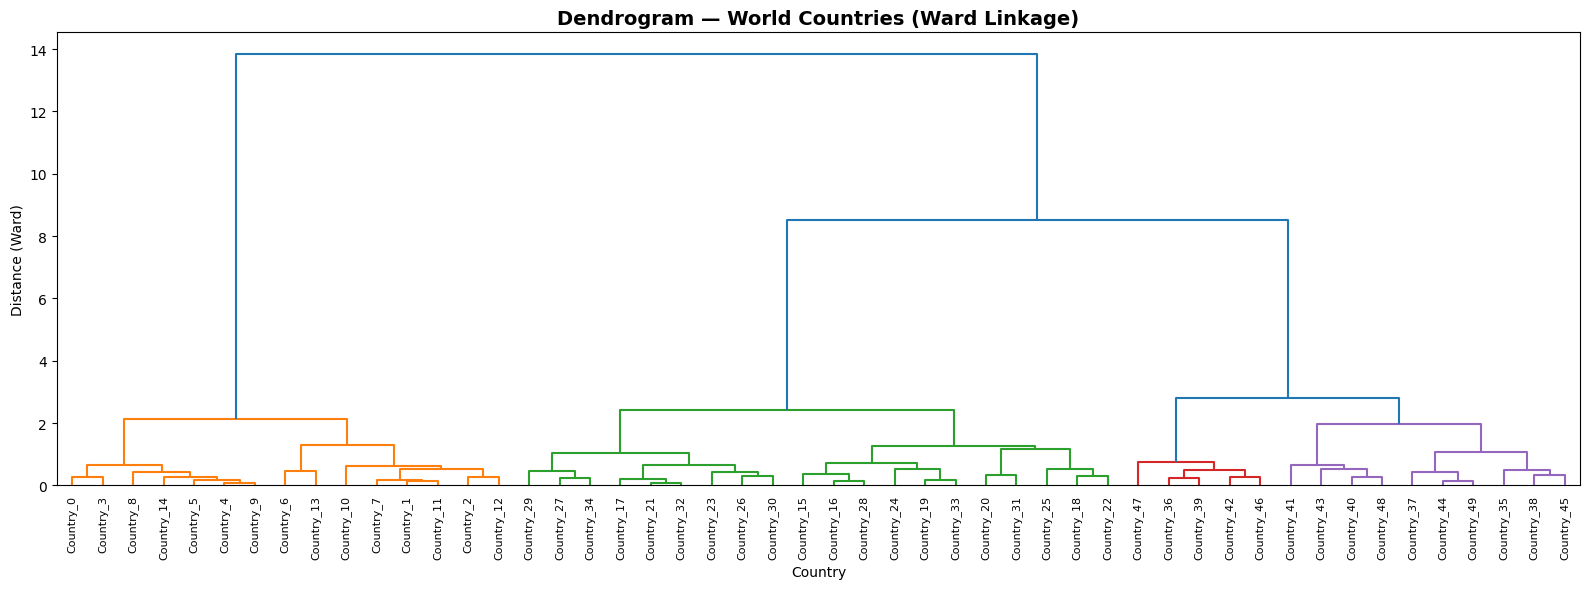

HOW TO READ A DENDROGRAM:
- The height of each merge line = distance between the merged clusters
- Tall branches = clusters that were very different before merging
- To get k clusters: draw a horizontal line, count the branches it cuts

From the dendrogram, where would you cut for 3 clusters? (height ≈ 2.8)


In [3]:
# Compute linkage matrix for dendrogram
linked = linkage(X_countries, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked, labels=countries['Country'].values,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=linked[-3, 2])
plt.title('Dendrogram — World Countries (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Country'); plt.ylabel('Distance (Ward)')
plt.tight_layout(); plt.show()

print('HOW TO READ A DENDROGRAM:')
print('- The height of each merge line = distance between the merged clusters')
print('- Tall branches = clusters that were very different before merging')
print('- To get k clusters: draw a horizontal line, count the branches it cuts')
print()
print(f'From the dendrogram, where would you cut for 3 clusters? (height ≈ {linked[-3, 2]:.1f})')


In [4]:
# Cut at 3, 4, 5 clusters
def label_cluster(child_mort, income, life_exp):
    """Assign a plain-English geopolitical label to a cluster summary."""
    if income > 25000 and life_exp > 75:
        return 'High-income developed'
    if income > 8000 and life_exp > 70:
        return 'Emerging / middle-income economy'
    if child_mort > 80 or life_exp < 60:
        return 'Low-income / least developed'
    return 'Lower-middle income'

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_countries)

    countries[f'Cluster_k{k}'] = labels
    print(f'\n=== k={k} clusters ===')
    for c in range(k):
        mask = labels == c
        avg = countries[mask][features].mean()
        label = label_cluster(avg["Child_Mortality"], avg["Income"], avg["Life_Expectancy"])
        print(f'  Cluster {c} ({mask.sum()} countries):')
        print(f'    Child mortality: {avg["Child_Mortality"]:.1f}  Income: ${avg["Income"]:,.0f}  Life exp: {avg["Life_Expectancy"]:.1f} years')
        print(f'    Geopolitical label: {label}')



=== k=3 clusters ===
  Cluster 0 (15 countries):
    Child mortality: 73.4  Income: $1,959  Life exp: 51.8 years
    Geopolitical label: Low-income / least developed
  Cluster 1 (15 countries):
    Child mortality: 8.0  Income: $34,914  Life exp: 78.0 years
    Geopolitical label: High-income developed
  Cluster 2 (20 countries):
    Child mortality: 28.1  Income: $8,290  Life exp: 64.7 years
    Geopolitical label: Lower-middle income

=== k=4 clusters ===
  Cluster 0 (20 countries):
    Child mortality: 28.1  Income: $8,290  Life exp: 64.7 years
    Geopolitical label: Lower-middle income
  Cluster 1 (15 countries):
    Child mortality: 8.0  Income: $34,914  Life exp: 78.0 years
    Geopolitical label: High-income developed
  Cluster 2 (10 countries):
    Child mortality: 68.7  Income: $1,836  Life exp: 55.4 years
    Geopolitical label: Low-income / least developed
  Cluster 3 (5 countries):
    Child mortality: 82.7  Income: $2,205  Life exp: 44.6 years
    Geopolitical label: Low

---
## ✅ Complete!

- **Agglomerative**: bottom-up merging — works well for small-medium datasets
- **Dendrogram**: visualises all possible cluster numbers at once
- **Ward linkage**: minimises within-cluster variance — usually best choice
- Cut height determines k — no need to specify k in advance